In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import BatchNormalization, Dropout, Input, Embedding, Flatten, Concatenate, Dense
from tensorflow.keras.metrics import MeanAbsoluteError, RootMeanSquaredError, R2Score
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Nadam

from Funcoes_Comuns import avaliar_modelo, registrar_modelo

In [2]:
# Definir a semente para reprodutibilidade
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

    Esse teste foi feito devido as 66 novas colunas dos dados do Censo Escolar serem numéricas.
    Modelo de Rede Neural lidam bem com dados numéricos, logo, pode ser sair melhor do que LGBM com o novo perfil de features

### 1. Modelo RNA -> DNN com Embedding, Dropout e Batch Normalization
Embedding para coluna CO_MUNICIPIO_ESC

In [3]:
# Obter dados
df_enem = pd.read_pickle('Bases\\Finais\\enem_censo_2023_full.pkl')

In [4]:
variaveis_alvo = ['NUM_NOTA_MT', 'NUM_NOTA_LC', 'NUM_NOTA_CN', 'NUM_NOTA_CH', 'NUM_NOTA_REDACAO']
grupo_previsao = ['NUM_NOTA_CH']

In [5]:
# 1. Separar a coluna de alta cardinalidade
municipio_col = 'CAT_CO_MUNICIPIO_ESC'
municipios = df_enem[municipio_col].astype(str)  # garantir string para LabelEncoder
X_features = df_enem.drop(columns=[municipio_col] + variaveis_alvo)

In [6]:
# 2. Codificar a coluna como inteiros
le_municipio = LabelEncoder()
municipios_encoded = le_municipio.fit_transform(municipios)

In [7]:
# 3. One-hot para as demais features categóricas
categorical_columns = X_features.select_dtypes(include=['category']).columns
X_features = pd.get_dummies(X_features, columns=categorical_columns, drop_first=True)

    f: demais features
    m: municipios

In [8]:
# 4. Separar treino/teste/validação para ambos
X_train_f, X_test_f, X_train_m, X_test_m, y_train, y_test = train_test_split(
    X_features, municipios_encoded, df_enem[grupo_previsao], test_size=0.2, random_state=seed
)
X_train_f, X_eval_f, X_train_m, X_eval_m, y_train, y_eval = train_test_split(
    X_train_f, X_train_m, y_train, test_size=0.15, random_state=seed
)

In [9]:
# 5. Normalizar demais features e y
# Normalizar X - Referência apenas conjunto de treino
X_scaler_emb = StandardScaler()
X_train_f = X_scaler_emb.fit_transform(X_train_f)
X_eval_f = X_scaler_emb.transform(X_eval_f)
X_test_f = X_scaler_emb.transform(X_test_f)

# Normalizar y - Referência apenas conjunto de treino (não há colunas booleanas)
y_scaler_emb = StandardScaler()
y_train = y_scaler_emb.fit_transform(y_train)
y_eval = y_scaler_emb.transform(y_eval)
y_test = y_scaler_emb.transform(y_test)

In [10]:
# 6. Converter dados para modelo - redes neurais esperam dados em numpy arrays
X_train_f = X_train_f.astype(np.float32)
X_eval_f = X_eval_f.astype(np.float32)
X_test_f = X_test_f.astype(np.float32)

y_train = y_train.astype(np.float32)
y_eval = y_eval.astype(np.float32)
y_test = y_test.astype(np.float32)

In [11]:
# 7. Modelo com Embedding, Dropout e BatchNormalization

# Inputs
input_features = Input(shape=(X_train_f.shape[1],), name='features')
input_municipio = Input(shape=(1,), name='municipio')

# Embedding
n_municipios = len(le_municipio.classes_)
embedding_dim = 16  # escolha um valor pequeno, ex: 8~32
x_municipio = Embedding(input_dim=n_municipios, output_dim=embedding_dim)(input_municipio)
x_municipio = Flatten()(x_municipio)

# Concatenar
x = Concatenate()([input_features, x_municipio])

In [12]:
# Camadas densas
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)
x = Dense(8, activation='relu')(x)
output = Dense(len(grupo_previsao), activation='linear')(x)

modelo = Model(inputs=[input_features, input_municipio], outputs=output)

In [13]:
# Parametros de parada
early_stopping = EarlyStopping(
    monitor='val_loss',           # Monitorar a perda no conjunto de validação
    patience=10,                  # Parar após n épocas sem melhoria
    mode='min',                   # Minimizar a perda
    restore_best_weights=True     # Restaurar os melhores pesos encontrados
)

# Compilar e treinar
modelo.compile(
    optimizer=Nadam(learning_rate=0.0005),
    loss='mse',
    metrics=[MeanAbsoluteError(), RootMeanSquaredError(), R2Score()]
)

In [14]:
start_time = time.time()

# Treinar modelo com embedding, dropout e batch normalization
history = modelo.fit(
    [X_train_f, X_train_m], y_train,
    validation_data=([X_eval_f, X_eval_m], y_eval),
    epochs=50,
    batch_size=512,
    callbacks=[early_stopping],
    verbose=1
)

tempo_treino = time.time() - start_time

Epoch 1/50
952/952 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 0.8525 - mean_absolute_error: 0.7311 - r2_score: 0.1446 - root_mean_squared_error: 0.9219 - val_loss: 0.7073 - val_mean_absolute_error: 0.6640 - val_r2_score: 0.2957 - val_root_mean_squared_error: 0.8410
Epoch 2/50
952/952 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 0.8525 - mean_absolute_error: 0.7311 - r2_score: 0.1446 - root_mean_squared_error: 0.9219 - val_loss: 0.7073 - val_mean_absolute_error: 0.6640 - val_r2_score: 0.2957 - val_root_mean_squared_error: 0.8410
Epoch 2/50
952/952 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.7143 - mean_absolute_error: 0.6685 - r2_score: 0.2835 - root_mean_squared_error: 0.8451 - val_loss: 0.6958 - val_mean_absolute_error: 0.6582 - val_r2_score: 0.3071 - val_root_mean_squared_error: 0.8342
Epoch 3/50
952/952 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 0.7143 - mean_absolute_error: 0.6685 - r2_score: 0.2835 - root_mean_squared_error: 0.8451 - val_loss: 0.6958 - val_mean_absolute_error: 0.65

In [15]:
# Avaliar o modelo no conjunto de teste
modelo.evaluate([X_test_f, X_test_m], y_test, verbose=1)

4479/4479 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.6851 - mean_absolute_error: 0.6527 - r2_score: 0.3141 - root_mean_squared_error: 0.8277
4479/4479 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.6851 - mean_absolute_error: 0.6527 - r2_score: 0.3141 - root_mean_squared_error: 0.8277


[0.6839982271194458, 0.651839017868042, 0.8270418643951416, 0.3127846121788025]

In [16]:
# Previsões
y_pred_drop = modelo.predict([X_test_f, X_test_m])

# Desnormalizar
y_test_desnorm = y_scaler_emb.inverse_transform(y_test)
y_pred_desnorm = y_scaler_emb.inverse_transform(y_pred_drop)
y_train_desnorm = y_scaler_emb.inverse_transform(y_train)

4479/4479 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step
4479/4479 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step


In [18]:
nome_experimento = 'Notas CH ENEM 2023'

# Registrar modelo no MLflow
registrar_modelo(experimento=nome_experimento,
                 parametros={
                        'batch_size': 512,
                        'epochs': len(history.history['loss']),
                        'loss': history.history['loss'][-1],
                        'val_loss': history.history['val_loss'][-1],
                        'mae': history.history['mean_absolute_error'][-1],
                        'rmse': history.history['root_mean_squared_error'][-1],
                        'r2_score': history.history['r2_score'][-1],
                        'tempo': tempo_treino,
                        'amostra': len(X_train_f),
                        'embedding_dim': embedding_dim,
                        'patience': early_stopping.patience,
                        'optimizer': 'Nadam',
                        'learning_rate': modelo.optimizer.learning_rate.numpy(),
                        'dropout_rate': 0.3,
                        'batch_normalization': True
                    },
                 X_train=X_train_f,
                 y_train=pd.DataFrame(y_train_desnorm, columns=grupo_previsao),
                 y_test=pd.DataFrame(y_test_desnorm, columns=grupo_previsao),
                 y_pred=pd.DataFrame(y_pred_desnorm, columns=grupo_previsao),
                 variavel_alvo= grupo_previsao[0],
                 modelo=modelo,
                 nome_modelo='modelo_RNA_censo_enem_embedding_dropout_batchnorm',
                 descricao_modelo='Modelo de RNA com embedding, dropout e batch normalization para o código do município para variáveis do ENEM e Censo'
                )

Successfully registered model 'modelo_RNA_censo_enem_embedding_dropout_batchnorm'.
2025/08/16 18:22:47 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: modelo_RNA_censo_enem_embedding_dropout_batchnorm, version 1


Modelo registrado com sucesso no MLflow: modelo_RNA_censo_enem_embedding_dropout_batchnorm
🏃 View run blushing-squid-76 at: http://127.0.0.1:9080/#/experiments/957135083854196683/runs/759cdc4e5e0a43b281b1d741413b65c4
🧪 View experiment at: http://127.0.0.1:9080/#/experiments/957135083854196683
Rastreamento do MLflow finalizado.


Created version '1' of model 'modelo_RNA_censo_enem_embedding_dropout_batchnorm'.


In [19]:
# Avaliação grupo treino
avaliar_modelo(y_train_desnorm,
               y_scaler_emb.inverse_transform(modelo.predict([X_train_f, X_train_m])), 
               "treino")

# Avaliação grupo teste
avaliar_modelo(y_test_desnorm,
               y_pred_desnorm,
               "teste")

15226/15226 ━━━━━━━━━━━━━━━━━━━━ 80s 5ms/step
MAE (treino): 54.4797
RMSE (treino): 69.1815
R2 (treino): 0.3318
MAE (teste): 55.1661
RMSE (teste): 69.9938
R2 (teste): 0.3128


    Não houve melhora aplicando um modelo de RNA, mesmo com mais variáveis numéricas.
    Houve uma pequena piora com a inclusão de mais features nas métricas.

In [20]:
# Salvar o modelo otimizado como um arquivo
modelo.save('Modelos\\modelo_RNA_censo_enem_embedding_dropout_batchnorm.keras')

### Análise de resultados do modelo com Dropout + BatchNorm

In [21]:
import matplotlib.pyplot as plt

# Função para customizar o gráfico conforme solicitado
def custom_plot(x, y1, y2, label1, label2, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, y1, label=label1)
    ax.plot(x, y2, label=label2)
    
    # Remover título
    # ax.set_title('')  # Não definir título
    
    # Customizar eixos principais
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('black')
    ax.spines['left'].set_linewidth(1.5)
    
    # Remover linhas de grade
    ax.grid(False)
    
    # Remover preenchimento
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    
    # Títulos dos eixos
    ax.set_xlabel(xlabel, fontname='Arial', fontsize=14, color='black')
    ax.set_ylabel(ylabel, fontname='Arial', fontsize=14, color='black')
    
    # Legenda com fonte 14
    ax.legend(fontsize=14)
    plt.show()

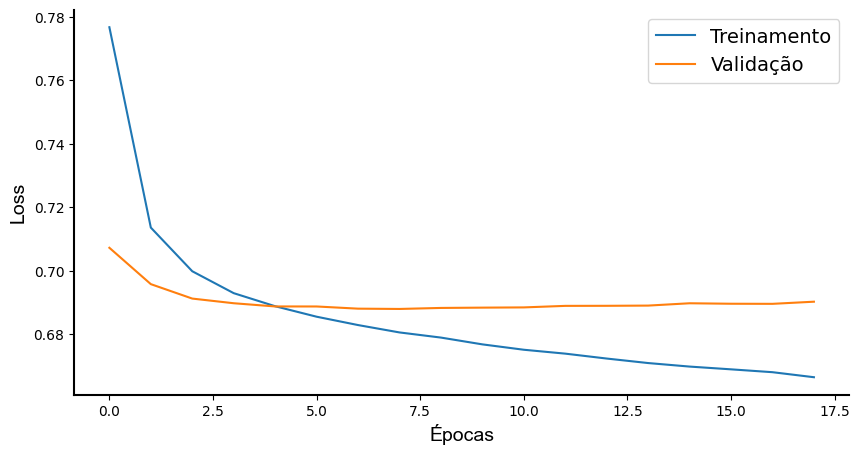

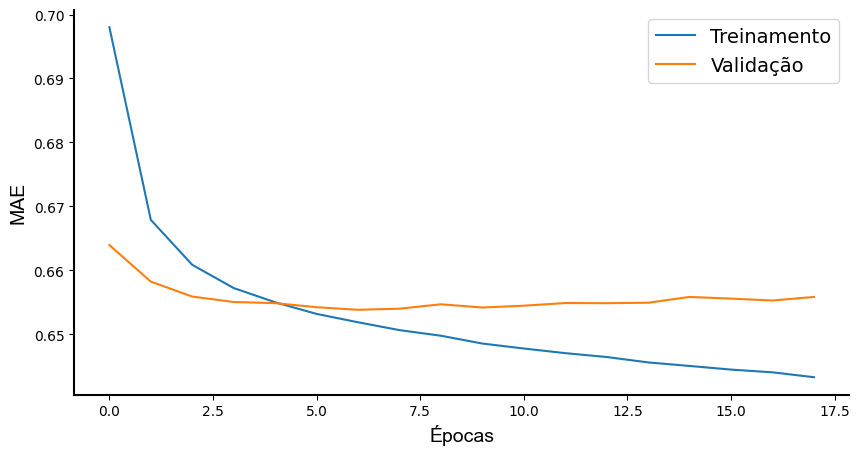

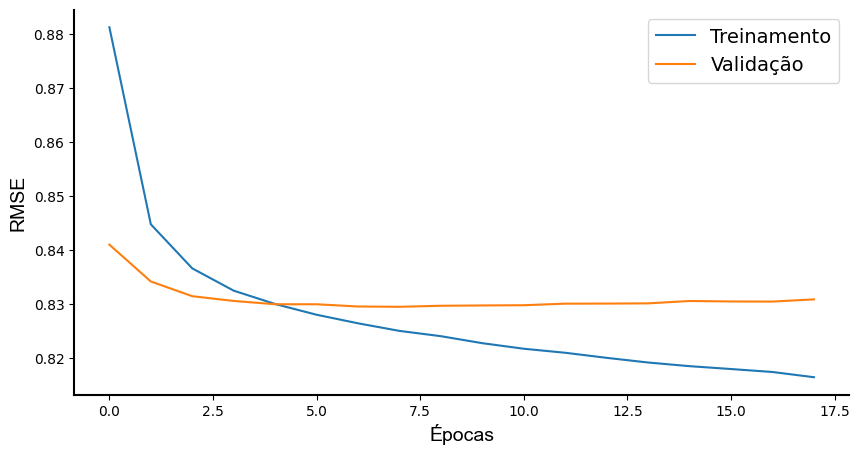

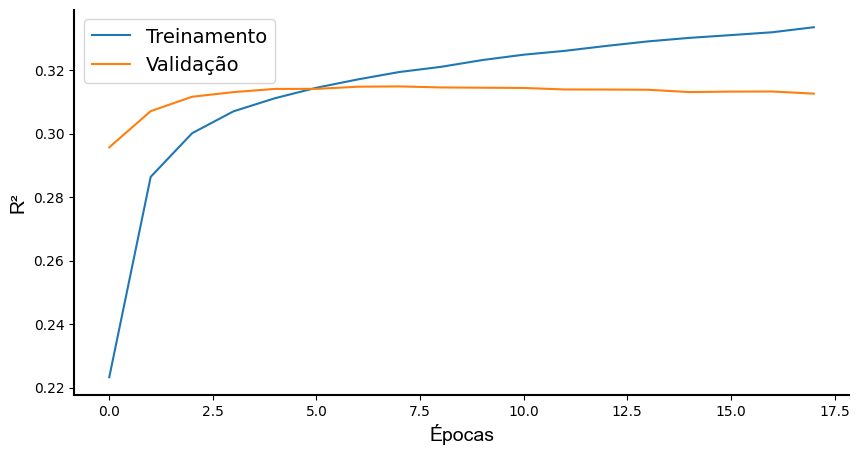

In [22]:
# Exemplo de uso da função custom_plot para os principais gráficos de treinamento

# Gráfico de perda (loss)
custom_plot(
    range(len(history.history['loss'])),
    history.history['loss'],
    history.history['val_loss'],
    'Treinamento',
    'Validação',
    'Épocas',
    'Loss'
)

# Gráfico de MAE
if 'mean_absolute_error' in history.history and 'val_mean_absolute_error' in history.history:
    custom_plot(
        range(len(history.history['mean_absolute_error'])),
        history.history['mean_absolute_error'],
        history.history['val_mean_absolute_error'],
        'Treinamento',
        'Validação',
        'Épocas',
        'MAE'
    )

# Gráfico de RMSE
if 'root_mean_squared_error' in history.history and 'val_root_mean_squared_error' in history.history:
    custom_plot(
        range(len(history.history['root_mean_squared_error'])),
        history.history['root_mean_squared_error'],
        history.history['val_root_mean_squared_error'],
        'Treinamento',
        'Validação',
        'Épocas',
        'RMSE'
    )

# Gráfico de R2 Score
if 'r2_score' in history.history and 'val_r2_score' in history.history:
    custom_plot(
        range(len(history.history['r2_score'])),
        history.history['r2_score'],
        history.history['val_r2_score'],
        'Treinamento',
        'Validação',
        'Épocas',
        'R²'
    )